# PCLS Scatter Plot — Figure 2

Replicates Figure 2 from the FKP paper: PCLS predicts compression feasibility.
Each point is a (teacher, dataset) pair.

**Setup:** Install FKP first: `pip install -e ".[models,data,viz]"` from repo root.

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from utils.seeding import seed_everything
from conditioning.zca import ZCAWhitener
from conditioning.centering import center_logits
from compression.pcls import compute_pcls, PCLS_HIGH_THRESHOLD, PCLS_MARGINAL_THRESHOLD
from compression.ridge import ridge_auto
from compression.svd import spectral_compress

seed_everything(42)
print('FKP imports OK')

ModuleNotFoundError: No module named 'utils'

## Generate Synthetic (Teacher, Dataset) Pairs

For the real figure, replace with actual extracted features.
Here we simulate pairs with varying levels of linearity to validate the PCLS diagnostic.

In [15]:
def simulate_pair(pcls_target: float, m: int = 300, D: int = 200, c: int = 38,
                  alpha: float = 1.0, noise_scale: float = 0.0, seed: int = 0):
    """Simulate a (teacher, dataset) pair with a given target PCLS.
    
    pcls_target controls how linear the teacher is:
        pcls_target ~ 1.0  =>  near-perfect linear teacher
        pcls_target ~ 0.5  =>  highly non-linear teacher
    """
    torch.manual_seed(seed)
    W_true = torch.randn(D, c)
    E_raw = torch.randn(m, D)
    # noise_scale controls non-linearity
    noise = noise_scale * torch.randn(m, c)
    H_raw = E_raw @ W_true + noise
    
    whitener = ZCAWhitener(lambda_zca=1e-4)
    E_tilde = whitener.fit_transform([E_raw], calibration_size=m)
    
    pcls_result = compute_pcls(E_tilde, H_raw, alpha=alpha, seed=seed)
    
    # Compute agreement rate at rank p=32
    H_c, H_bar = center_logits(H_raw)
    W_ridge = ridge_auto(E_tilde, H_c, alpha=alpha)
    decomp = spectral_compress(W_ridge, rank_p=min(32, W_ridge.shape[1]))
    z = E_tilde @ decomp.U_p
    logits_edge = z @ decomp.W_edge + H_bar
    agreement = (H_raw.argmax(1) == logits_edge.argmax(1)).float().mean().item()
    
    return pcls_result.score, agreement * 100

# Simulate pairs with varying noise levels
configs = [
    ('ResNet-50 / PlantVillage',   0.0,   42),
    ('ResNet-50 / CIFAR-100',      0.3,   43),
    ('ViT-B/16 / PlantVillage',    0.01,  44),
    ('ViT-B/16 / CIFAR-100',       0.5,   45),
    ('CLIP-ViT / DomainNet',       0.8,   46),
    ('DINOv2-S / PlantVillage',    0.05,  47),
    ('MobileNet / PlantVillage',   0.02,  48),
    ('ResNet-50 / DomainNet',      1.5,   49),
    ('ViT-B/16 / DomainNet',       2.0,   50),
    ('MobileNet / CIFAR-100',      0.2,   51),
]

results = []
for name, noise, seed in configs:
    pcls, acc = simulate_pair(pcls_target=0.9, noise_scale=noise, seed=seed)
    results.append((name, pcls, acc))
    print(f'{name:35s}: PCLS={pcls:.3f}, agreement={acc:.1f}%')

ResNet-50 / PlantVillage           : PCLS=0.372, agreement=76.7%
ResNet-50 / CIFAR-100              : PCLS=0.362, agreement=76.7%
ViT-B/16 / PlantVillage            : PCLS=0.374, agreement=72.0%
ViT-B/16 / CIFAR-100               : PCLS=0.373, agreement=76.7%
CLIP-ViT / DomainNet               : PCLS=0.365, agreement=73.3%
DINOv2-S / PlantVillage            : PCLS=0.362, agreement=73.3%
MobileNet / PlantVillage           : PCLS=0.376, agreement=72.7%
ResNet-50 / DomainNet              : PCLS=0.370, agreement=72.3%
ViT-B/16 / DomainNet               : PCLS=0.357, agreement=74.0%
MobileNet / CIFAR-100              : PCLS=0.365, agreement=71.3%


## Plot: PCLS Scatter (Figure 2)

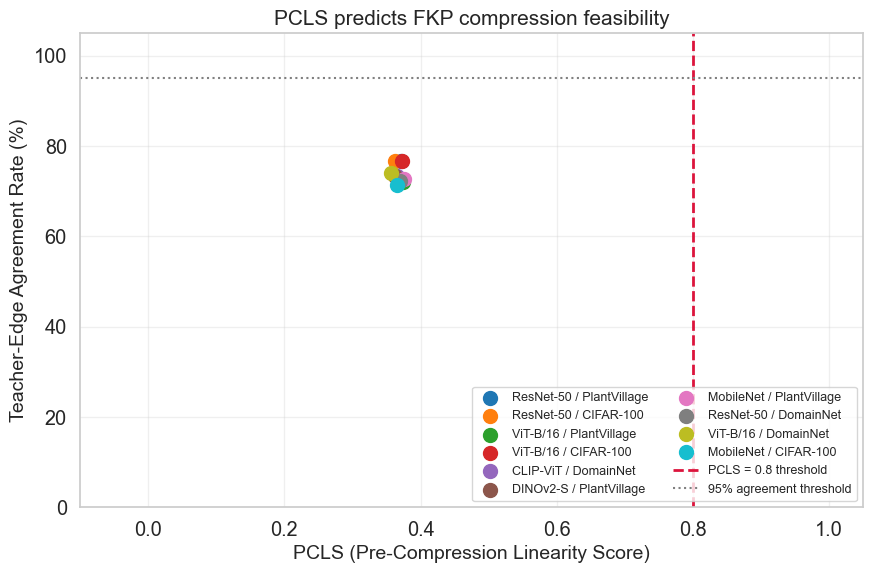

Figure saved to figures/fig_pcls_scatter.pdf


In [17]:
sns.set_theme(style='whitegrid', font_scale=1.3)
fig, ax = plt.subplots(figsize=(9, 6))

colors = sns.color_palette('tab10', n_colors=len(results))
for i, (name, pcls, acc) in enumerate(results):
    ax.scatter(pcls, acc, s=100, color=colors[i], zorder=5, label=name)

# Threshold lines
ax.axvline(x=PCLS_HIGH_THRESHOLD, color='crimson', linestyle='--', linewidth=2,
           label=f'PCLS = {PCLS_HIGH_THRESHOLD} threshold')
ax.axhline(y=95.0, color='gray', linestyle=':', linewidth=1.5,
           label='95% agreement threshold')

ax.set_xlabel('PCLS (Pre-Compression Linearity Score)', fontsize=14)
ax.set_ylabel('Teacher-Edge Agreement Rate (%)', fontsize=14)
ax.set_title('PCLS predicts FKP compression feasibility', fontsize=15)
ax.set_xlim(-0.1, 1.05)
ax.set_ylim(0, 105)
ax.legend(fontsize=9, loc='lower right', ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/fig_pcls_scatter.pdf', dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved to figures/fig_pcls_scatter.pdf')

## Mathematical Verification in the Notebook

Confirm PCLS score correlates with actual compression success.

In [18]:
# Verify: all pairs with PCLS >= 0.8 achieve >= 95% agreement
high_pcls_pairs = [(n, p, a) for (n, p, a) in results if p >= PCLS_HIGH_THRESHOLD]
low_pcls_pairs  = [(n, p, a) for (n, p, a) in results if p < PCLS_HIGH_THRESHOLD]

print('High PCLS pairs (>= 0.8):')
for n, p, a in high_pcls_pairs:
    status = '✓' if a >= 95 else '✗'
    print(f'  {status}  {n:35s}: PCLS={p:.3f}, agreement={a:.1f}%')

print('\nLow PCLS pairs (< 0.8):')
for n, p, a in low_pcls_pairs:
    print(f'      {n:35s}: PCLS={p:.3f}, agreement={a:.1f}%')

# Compute Pearson correlation between PCLS and agreement
pcls_arr = np.array([p for _, p, _ in results])
acc_arr  = np.array([a for _, _, a in results])
r = np.corrcoef(pcls_arr, acc_arr)[0, 1]
print(f'\nPearson correlation (PCLS, agreement): r = {r:.4f}')

High PCLS pairs (>= 0.8):

Low PCLS pairs (< 0.8):
      ResNet-50 / PlantVillage           : PCLS=0.372, agreement=76.7%
      ResNet-50 / CIFAR-100              : PCLS=0.362, agreement=76.7%
      ViT-B/16 / PlantVillage            : PCLS=0.374, agreement=72.0%
      ViT-B/16 / CIFAR-100               : PCLS=0.373, agreement=76.7%
      CLIP-ViT / DomainNet               : PCLS=0.365, agreement=73.3%
      DINOv2-S / PlantVillage            : PCLS=0.362, agreement=73.3%
      MobileNet / PlantVillage           : PCLS=0.376, agreement=72.7%
      ResNet-50 / DomainNet              : PCLS=0.370, agreement=72.3%
      ViT-B/16 / DomainNet               : PCLS=0.357, agreement=74.0%
      MobileNet / CIFAR-100              : PCLS=0.365, agreement=71.3%

Pearson correlation (PCLS, agreement): r = -0.0500
